## Logistic Regression

Logistic Regression is usually used when data are categorical.
First we import all the necessary libs.

In [1]:
# import everything we need first
import pandas as pd
import matplotlib.pyplot as plt

We are going to import data from `Logistic_Reg_Infected.csv`
For better understanding, we can see the independent variable (x) as the age of children, and the dependent variable (y) as whether the child is infected by some disease.

0 means not infected
1 means infected
As the dependent variable only has two possible values, 0 or 1, we can use a binary logistic model to predict.

In [2]:
# read in data from the file
df = pd.read_csv('Logistic_Reg_Infected.csv')
df.head() # show the first five values

,age,sleep,infected
0,1.2,5.0,0
1,2.0,5.6,0
2,2.2,6.5,0
3,12.1,10.3,1
4,6.3,5.3,0


In [3]:
df.tail() # show the last five values

,age,sleep,infected
14,4.0,9.0,0
15,12.3,8.0,1
16,13.0,11.0,0
17,14.0,9.7,1
18,18.5,8.5,1


In [4]:
df.describe()

,age,sleep,infected
count,19.000000,19.000000,19.000000
mean,8.803158,8.326316,0.421053
std,4.474119,1.830253,0.507257
min,1.200000,5.000000,0.000000
25%,6.480000,7.000000,0.000000
50%,9.000000,8.800000,0.000000
75%,12.050000,9.750000,1.000000
max,18.500000,11.000000,1.000000


# Visualize the data

In [5]:
# Remember the filtering
df_0 = df[df['infected'] == 0] # filter all column 'infected' is 0
df_1 = df[df['infected'] == 1]

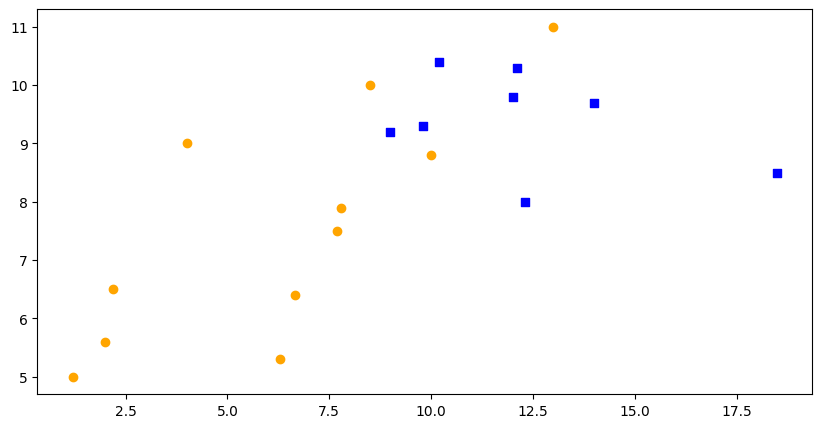

In [6]:
# in this plot, data points above the line are categorized as 1, those below the line are categorized as 0
# this line is our regression model's decision boundary
# This line creates a new figure and a set of subplots. The figsize=(10,5) argument sets the size of the figure to be 10 units wide and 5 units tall.
# fig is the Figure object, and ax is the AxesSubplot object where the data will be plotted.

fig, ax = plt.subplots(figsize=(10,5))
ax.scatter(df_0['age'], df_0['sleep'], c= 'orange') # class = 0 circle points 
ax.scatter(df_1['age'], df_1['sleep'], marker = 's', c='blue') # class = 1 square points
# x_min, x_max = ax.get_xlim()

## Model training

We are going to use the same technic to build a Logistic Regression model.


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

logReg = LogisticRegression()
x = df[['age', 'sleep']]
y = df['infected']    # Classification : infected = 0 or 1



In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.head()

,age,sleep
8,8.5,10.0
16,13.0,11.0
3,12.1,10.3
13,12.0,9.8
15,12.3,8.0


In [9]:
print(y_test)

0     0
5     0
11    1
1     0
Name: infected, dtype: int64


In [10]:
print(x_train.shape)

(15, 2)


In [11]:
print(x_test)

      age  sleep
0    1.20    5.0
5    6.66    6.4
11  10.20   10.4
1    2.00    5.6


In [12]:
logReg.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# Evaluate Model with Accuracy Score

We can use our model to predict values.

In [13]:
from sklearn.metrics import accuracy_score

y_pred = logReg.predict(x_test)
print('Y_Pred:',y_pred)

Y_Pred: [0 0 0 0]


In [14]:
print(y_test)
accuracy_score(y_test, y_pred)

0     0
5     0
11    1
1     0
Name: infected, dtype: int64


0.75

In [15]:
from sklearn.metrics import confusion_matrix

# Let's say these are your true and predicted labels
y_test = [1, 0, 1, 1, 0, 1, 0, 0, 1, 0] # actual labels reserved for test
y_pred = [1, 0, 1, 0, 0, 1, 1, 0, 1, 0] # predicted values

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[4 1]
 [1 4]]


In [16]:
logReg.predict(x_test)  # prediction value of x_test

array([0, 0, 0, 0])

# Predict 
Predict with some values

In [17]:
# predict y when x1 = 7.5 and x2 = 0.65
logReg.predict(pd.DataFrame([[7.5, 0.65]], columns=x.columns))

array([0])

In [18]:
# predict y when x1 = 10 and x2 = 0.74
print(logReg.predict(pd.DataFrame([[18, 6.74]], columns=x.columns)))

[1]
